In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("../Telco_customer_churn.xlsx")
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [3]:
df.shape

(7043, 33)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [5]:
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors = "coerce")

In [6]:
df["Total Charges"].isnull().sum()

np.int64(11)

In [7]:
df = df.dropna(subset=["Total Charges"])

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7032 non-null   object 
 1   Count              7032 non-null   int64  
 2   Country            7032 non-null   object 
 3   State              7032 non-null   object 
 4   City               7032 non-null   object 
 5   Zip Code           7032 non-null   int64  
 6   Lat Long           7032 non-null   object 
 7   Latitude           7032 non-null   float64
 8   Longitude          7032 non-null   float64
 9   Gender             7032 non-null   object 
 10  Senior Citizen     7032 non-null   object 
 11  Partner            7032 non-null   object 
 12  Dependents         7032 non-null   object 
 13  Tenure Months      7032 non-null   int64  
 14  Phone Service      7032 non-null   object 
 15  Multiple Lines     7032 non-null   object 
 16  Internet Service   7032 non-n

In [9]:
df["Senior Citizen"].unique()

array(['No', 'Yes'], dtype=object)

In [13]:
df = df.drop(columns=[
    "CustomerID", "Count", "Lat Long", "Latitude", "Longitude", "Zip Code", "Country", "State", "City"
])

# Churn Distribution + Segment Analysis

- Churn Distribution
- Churn by Contract Type (Big Signal)
- Churn by Tenure
- Churn by Monthly Charges

In [14]:
df["Churn Label"].value_counts(normalize=True)*100

Churn Label
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

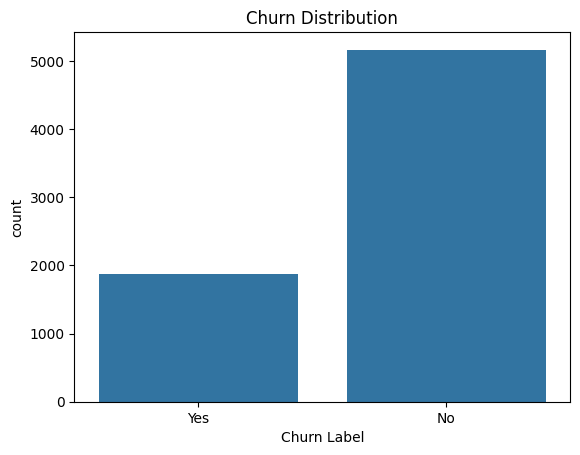

In [15]:
sns.countplot(x="Churn Label", data=df)
plt.title("Churn Distribution")
plt.show()

**Approximately 26.6% of customers have churned, indicating a moderate churn rate that warrants predictive modeling and retention strategies.**

In [16]:
pd.crosstab(df["Contract"], df["Churn Label"], normalize="index")*100

Churn Label,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


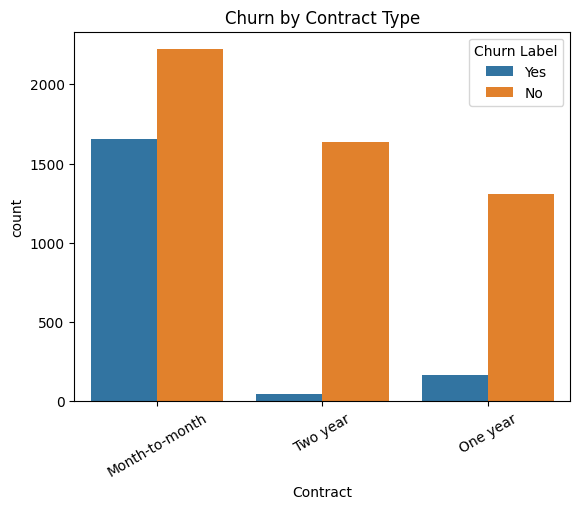

In [18]:
sns.countplot(x="Contract", hue = "Churn Label", data=df)
plt.xticks(rotation=30)
plt.title("Churn by Contract Type")
plt.show()

# Insights

- **Customers on month-to-month contracts are ~15x more likely to churn than customers on two-year contracts.**
- **Long-term contracts dramatically reduce churn risk.**
- **Contract type is almost certainly going to be one of your strongest predictive features**

# Advices:

- Push Customers towards long-term contracts.
- Offer discounts for annual commitments.
- Target month-to-month customers with retention campaigns.

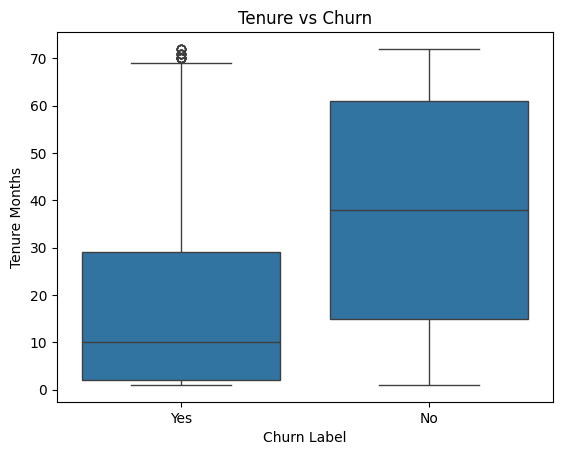

In [19]:
sns.boxplot(x="Churn Label", y="Tenure Months", data=df)
plt.title("Tenure vs Churn")
plt.show()

# Whar is shown
- Median tenure for churned customers ~= around 10 months
- Median tenure for non-churned customers ~= around 38 months

# Interpretation:

- Customers are most vulnerable in their early lifecycle.
- Long-tenure customers are significantly more stable
- Retention efforts should focus heavily on the first 6-12 months.

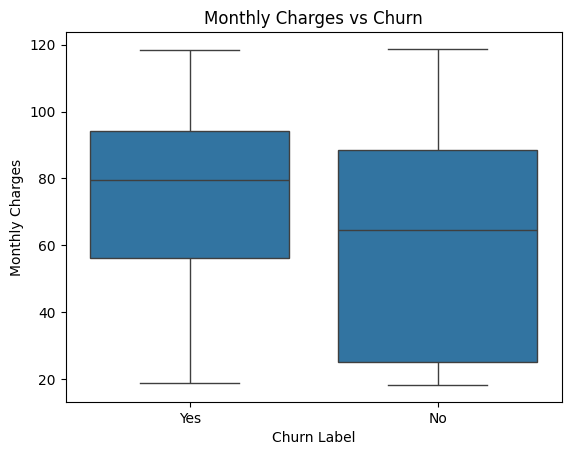

In [21]:
sns.boxplot(x="Churn Label", y="Monthly Charges", data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

# What this thing shows:
- Median monthly charges for churners is clearly higher than non-churners
- Churners cluster more in higher price ranges

# Interpretations:
- Price sensitivity likely plays a role.
- Customers paying higher monthly fees are more likely to leave
- Bunding, discounts, or value communication could reduce churn in high-paying segments

OVERALL RANKING FOR THESE:

- Contract type(Very Strong)
- Tenure(Very Strong)
- Monthly Charges(Moderate signal)

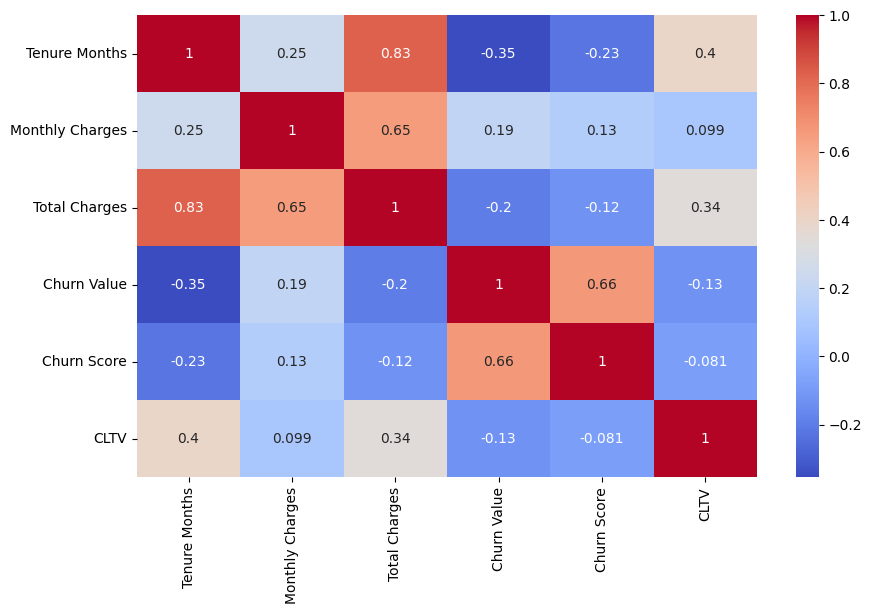

In [22]:
num_cols = df.select_dtypes(include=["int64", "float64"])
corr = num_cols.corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

## 1. Tenure Vs Total Charges -> 0.83
- Very Strong positive correlation.
Makes perfect sense:
The Longer someone stays, the more they pay in total.

No surpise. No magic. Just arithmetic.

## 2. Tenure Vs Churn Value -> -0.35
- Moderate negative correlation.

Interpretation:
As tenure increases, churn probability decreases.

## 3. Monthly Charges Vs Churn Value -> 0.19
- Weak positive correlation.

So yes, higher charges increase churn slightly.
But it's not the main driver.

- Matches earlier intution -> Monthly charges matter, but not as strongly as tenure or contract.

## 4. Churn Value vs Churn Score -> 0.66
- High Correlation
Makes sense. Churn score was likely derived from churn risk.

## 5. CLTV vs Tenure
- Moderate Positive.
- Longer customers are more valuable. Schocking revelation.

# 5 Business Insights

1. Month-to-month customers exhibit significantly higher churn rates compared to long-term contract customers.
2. Customers with low tenure are substantially more likely to churn, indicating early-stage vulnearability.
3. Higher monthly charges are associated with increased churn probability. though the effect is moderate.
4. Total charges strongly correlate with tenure, suggesting customer lifetime value grows with retention.
5. Contract structure and customer lifecycle stage appear to be the most critical drivers of churn behavior.